# Análisis de pruebas de pitch – plataforma autonivelante (Arduino UNO + MPU6050)
Formato de cada línea del .txt (monitor serial con timestamp):
`HH:MM:SS.mmm -> millis,roll,pitch`

Prueba: las ruedas delanteras suben a una rampa (5 cm de alto) y las traseras quedan en el piso,
así que la plataforma se inclina ≈ 11° de forma gradual. El MPU6050 mide sobre la plataforma,
es decir, el ángulo medido es el **error residual** después de la corrección de los actuadores.

**PRUEBAS PITCH SIN CONTROL**

In [ ]:
# Celda 1: librerías y parámetros
import re, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, welch

# ---------------- GEOMETRÍA DEL PROTOTIPO ----------------
L_MM          = 255.0   # distancia par delantero – par trasero de actuadores (mm)
CARRERA_MM    = 50.0    # carrera de cada actuador (mm)
RAMPA_ALTO_MM = 50.0    # altura de la rampa (mm)
RAMPA_LARGO_MM = 200.0  # largo de la rampa (mm)
TILT_DEG      = 11.0    # inclinación final a la que se somete la plataforma (°)

# ---------------- PARÁMETROS DEL ANÁLISIS ----------------
BAND_DEG      = 0.5     # banda de "error aceptable" (usa tu banda muerta, °)
LOBULO_MIN_DEG = 2.5    # un evento cuenta como "excursión" si su pico supera esto (°)
ONSET_MIN_DEG = 0.3     # umbral para marcar el inicio de una excursión (°)
GAP_S         = 0.3     # huecos menores a esto (s) no separan una excursión
BASELINE_S    = 1.0     # s iniciales usados como línea base (reposo)
FINAL_S       = 1.0     # s finales usados como estado estacionario
SMOOTH_S      = 0.10    # ventana del suavizado Savitzky-Golay (s)
OUT_DIR       = 'resultados'
os.makedirs(OUT_DIR, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})


In [ ]:
# Celda 2: referencia geométrica y chequeo de saturación
rad = np.radians
th_geom   = np.degrees(np.arctan(RAMPA_ALTO_MM / L_MM))   # inclinación por geometría
th_max    = np.degrees(np.arctan(CARRERA_MM / L_MM))      # máx. inclinación compensable
th_rampa  = np.degrees(np.arctan(RAMPA_ALTO_MM / RAMPA_LARGO_MM))  # pendiente de la rampa
print(f'Inclinación por geometría (5 cm sobre {L_MM/10:.1f} cm): {th_geom:.2f}°')
print(f'Máx. inclinación compensable con la carrera: {th_max:.2f}°')
print(f'Pendiente de la rampa: {th_rampa:.2f}°')
print(f'Carrera necesaria / disponible: {RAMPA_ALTO_MM:.0f} mm / {CARRERA_MM:.0f} mm '
      f'→ margen {CARRERA_MM - RAMPA_ALTO_MM:.0f} mm')

def grados_a_mm(g):
    """Desnivel equivalente en el extremo (mm) para un ángulo de pitch g (°)."""
    return L_MM * np.tan(rad(g))


Inclinación por geometría (5 cm sobre 25.5 cm): 11.09°
Máx. inclinación compensable con la carrera: 11.09°
Pendiente de la rampa: 14.04°
Carrera necesaria / disponible: 50 mm / 50 mm → margen 0 mm


In [ ]:
# Celda 3: cargar archivos (sube los .txt o usa los que ya estén en la carpeta)
try:
    from google.colab import files
    subidos = files.upload()          # selecciona PitchV1.txt ... PitchV8.txt
    rutas = list(subidos.keys())
except ImportError:                   # fuera de Colab: busca en la carpeta actual
    rutas = glob.glob('*Pitch*.txt')

def num_prueba(ruta):
    m = re.search(r'V(\d+)', os.path.basename(ruta))
    return int(m.group(1)) if m else 0

rutas = sorted(rutas, key=num_prueba)
print('Archivos:', [os.path.basename(r) for r in rutas])


Saving SinControlV9.txt to SinControlV9.txt
Saving SinControlV10.txt to SinControlV10.txt
Saving SinControlV1.txt to SinControlV1.txt
Saving SinControlV8.txt to SinControlV8.txt
Saving SinControlV7.txt to SinControlV7.txt
Saving SinControlV6.txt to SinControlV6.txt
Saving SinControlV5.txt to SinControlV5.txt
Saving SinControlV4.txt to SinControlV4.txt
Saving SinControlV3.txt to SinControlV3.txt
Saving SinControlV2.txt to SinControlV2.txt
Archivos: ['SinControlV1.txt', 'SinControlV2.txt', 'SinControlV3.txt', 'SinControlV4.txt', 'SinControlV5.txt', 'SinControlV6.txt', 'SinControlV7.txt', 'SinControlV8.txt', 'SinControlV9.txt', 'SinControlV10.txt']


In [ ]:
# Celda 4: lectura robusta (ignora "ERROR: MPU6050...", basura serial, timestamps)
LINEA = re.compile(r'(\d+),(-?\d+(?:\.\d+)?),(-?\d+(?:\.\d+)?)\s*$')

def cargar(ruta):
    filas = []
    with open(ruta, 'r', errors='ignore') as f:
        for linea in f:
            m = LINEA.search(linea.strip())
            if m:
                filas.append(tuple(float(x) for x in m.groups()))
    df = pd.DataFrame(filas, columns=['millis', 'roll', 'pitch'])   # <- orden real
    df = df[df['millis'].diff().fillna(1) > 0].reset_index(drop=True)
    df['t'] = (df['millis'] - df['millis'].iloc[0]) / 1000.0
    return df

datos = {f'V{num_prueba(r)}': cargar(r) for r in rutas}

resumen_carga = pd.DataFrame({
    k: {'muestras': len(d),
        'duración (s)': round(d['t'].iloc[-1], 2),
        'dt mediano (ms)': d['millis'].diff().median(),
        'fs (Hz)': round(1000 / d['millis'].diff().median(), 1),
        'huecos >50 ms': int((d['millis'].diff() > 50).sum())}
    for k, d in datos.items()}).T
display(resumen_carga) if 'display' in globals() else print(resumen_carga)


     muestras  duración (s)  dt mediano (ms)  fs (Hz)  huecos >50 ms
V1     1057.0          9.53              9.0    111.1            0.0
V2     1318.0         11.88              9.0    111.1            0.0
V3     1032.0          9.30              9.0    111.1            0.0
V4     1177.0         10.61              9.0    111.1            0.0
V5     1240.0         11.21              9.0    111.1            0.0
V6     1161.0         10.48              9.0    111.1            0.0
V7     1190.0         10.72              9.0    111.1            0.0
V8     1122.0         10.13              9.0    111.1            0.0
V9     1184.0         10.69              9.0    111.1            0.0
V10    1050.0          9.55              9.0    111.1            1.0


In [ ]:
# Celda 5: detección de excursiones y métricas
trapecio = getattr(np, 'trapezoid', None) or np.trapz   # compatible NumPy 1.x y 2.x

def suavizar(x, fs):
    v = int(round(SMOOTH_S * fs)); v += (v % 2 == 0); v = max(v, 5)
    return savgol_filter(x, v, 3)

def encontrar_excursiones(t, xs):
    """Tramos consecutivos con |pitch| > BAND, del mismo signo y sin huecos > GAP_S."""
    idx = np.flatnonzero(np.abs(xs) > BAND_DEG)
    if len(idx) == 0:
        return []
    tramos, ini, prev = [], idx[0], idx[0]
    for i in idx[1:]:
        if (t[i] - t[prev] > GAP_S) or (np.sign(xs[i]) != np.sign(xs[prev])):
            tramos.append((ini, prev)); ini = i
        prev = i
    tramos.append((ini, prev))
    return tramos

def analizar_prueba(d):
    t = d['t'].values
    fs = 1 / np.median(np.diff(t))
    x = d['pitch'].values
    base_mask = t <= t[0] + BASELINE_S
    base, ruido = x[base_mask].mean(), x[base_mask].std()
    xc = x - base                                   # línea base restada
    xs = suavizar(xc, fs)
    w = np.gradient(xs, t)                          # velocidad angular (°/s)

    umbral_on = max(5 * ruido, ONSET_MIN_DEG)
    excursiones = []
    for (a, b) in encontrar_excursiones(t, xs):
        i_pk = a + np.argmax(np.abs(xs[a:b + 1]))
        if abs(xc[i_pk]) < LOBULO_MIN_DEG:
            continue                                # transitorios menores
        # inicio: retrocede hasta que |xs| cae bajo el umbral de inicio
        i_on = i_pk
        while i_on > 0 and abs(xs[i_on]) > umbral_on:
            i_on -= 1
        i_fin = b                                   # último instante fuera de banda
        tramo = slice(i_on, i_fin + 1)
        excursiones.append(dict(
            signo='+' if xc[i_pk] > 0 else '-',
            t_inicio=t[i_on], t_pico=t[i_pk], t_fin=t[i_fin],
            pico=xc[i_pk], pico_abs=abs(xc[i_pk]),
            pico_mm_equiv=grados_a_mm(abs(xc[i_pk])),
            pico_pct_inclinacion=100 * abs(xc[i_pk]) / TILT_DEG,
            t_subida=t[i_pk] - t[i_on],
            t_recuperacion=t[i_fin] - t[i_pk],
            duracion=t[i_fin] - t[i_on],
            pendiente_max=np.max(np.abs(w[i_on:i_pk + 1])) if i_pk > i_on else np.nan,
            area_error=trapecio(np.abs(xc[tramo]), t[tramo]),   # °·s
            i_on=i_on, i_pk=i_pk, i_fin=i_fin))
    for k, e in enumerate(excursiones, 1):
        e['n'] = k

    # meseta entre la 1.ª y la 2.ª excursión (plataforma ya corregida sobre la rampa)
    meseta = np.nan
    if len(excursiones) >= 2:
        a, b = excursiones[0]['i_fin'], excursiones[1]['i_on']
        if b > a and t[b] - t[a] > 0.3:
            meseta = xc[a:b].mean()

    tail = t >= t[-1] - FINAL_S
    resumen = dict(
        n_excursiones=len(excursiones),
        secuencia=''.join(e['signo'] for e in excursiones),
        meseta_medio=meseta, final=xc[tail].mean(),
        final_std=xc[tail].std(),
        rms_total=np.sqrt(np.mean(xc ** 2)),
        roll_pico_a_pico=np.ptp(d['roll'].values - d['roll'].values[base_mask].mean()),
        ruido_reposo=ruido)
    return excursiones, resumen, xc, xs, w

exc_rows, res_rows, señales = [], [], {}
for nombre, d in datos.items():
    exc, res, xc, xs, w = analizar_prueba(d)
    señales[nombre] = dict(xc=xc, xs=xs, w=w, exc=exc)
    res['prueba'] = nombre; res_rows.append(res)
    for e in exc:
        exc_rows.append({**{k: v for k, v in e.items() if not k.startswith('i_')},
                         'prueba': nombre})

df_res = pd.DataFrame(res_rows).set_index('prueba')
df_exc = pd.DataFrame(exc_rows).set_index(['prueba', 'n'])

cols_exc = ['signo', 't_inicio', 't_pico', 'pico', 'pico_mm_equiv',
            'pico_pct_inclinacion', 't_subida', 't_recuperacion',
            'pendiente_max', 'area_error']
print('=== Excursiones detectadas por prueba (ordenadas en el tiempo) ===')
tabla_exc = df_exc[cols_exc].round(3)
display(tabla_exc) if 'display' in globals() else print(tabla_exc)
print('\n=== Resumen por prueba ===')
tabla_res = df_res.round(3)
display(tabla_res) if 'display' in globals() else print(tabla_res)

print(f"\nPico máximo observado: {df_exc['pico_abs'].max():.2f}° "
      f"({df_exc['pico_mm_equiv'].max():.1f} mm equivalentes) | "
      f"inclinación aplicada: {TILT_DEG}° | límite de compensación: {th_max:.1f}°")


=== Excursiones detectadas por prueba (ordenadas en el tiempo) ===
         signo  t_inicio  t_pico    pico  pico_mm_equiv  pico_pct_inclinacion  \
prueba n                                                                        
V1     1     +     4.202   9.475  11.616         52.417               105.598   
V2     1     +     5.286   6.855  10.875         48.991                98.866   
V3     1     +     4.341   9.296  10.934         49.262                99.400   
V4     1     +     4.613  10.445  11.135         50.191               101.228   
V5     1     +     5.235  11.193  10.703         48.197                97.301   
V6     1     +     4.684  10.478  10.698         48.172                97.251   
V7     1     +     4.451   6.445  10.658         47.988                96.889   
V8     1     +     5.117  10.126  10.955         49.360                99.593   
V9     1     +     4.521  10.515  11.165         50.329               101.500   
V10    1     +     4.625   9.553  10.974  

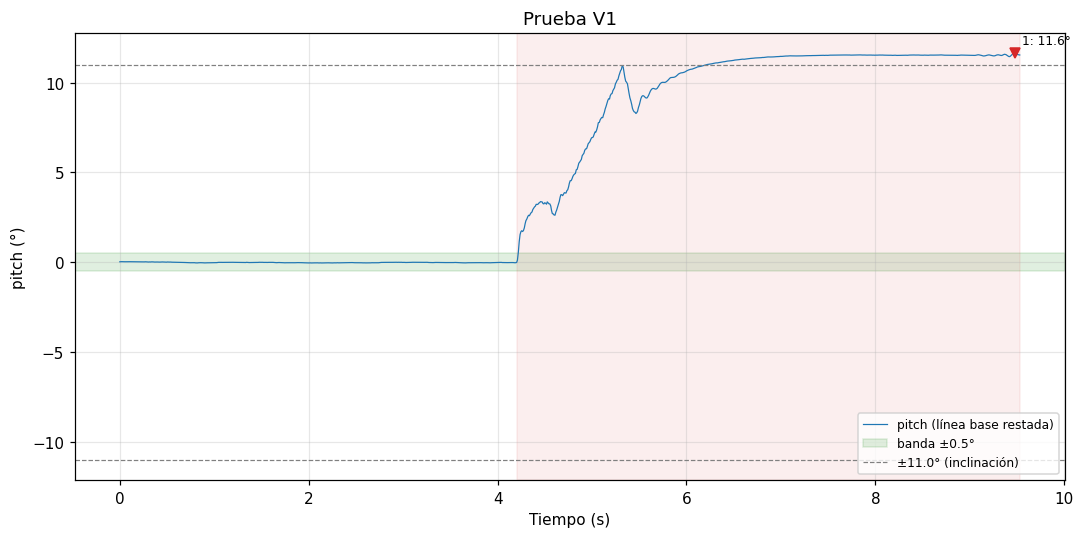

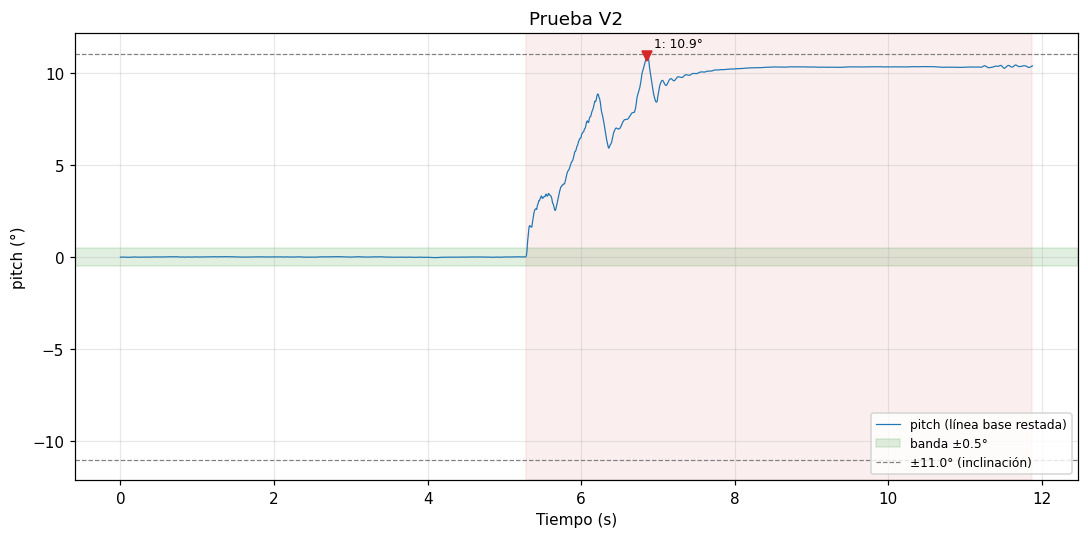

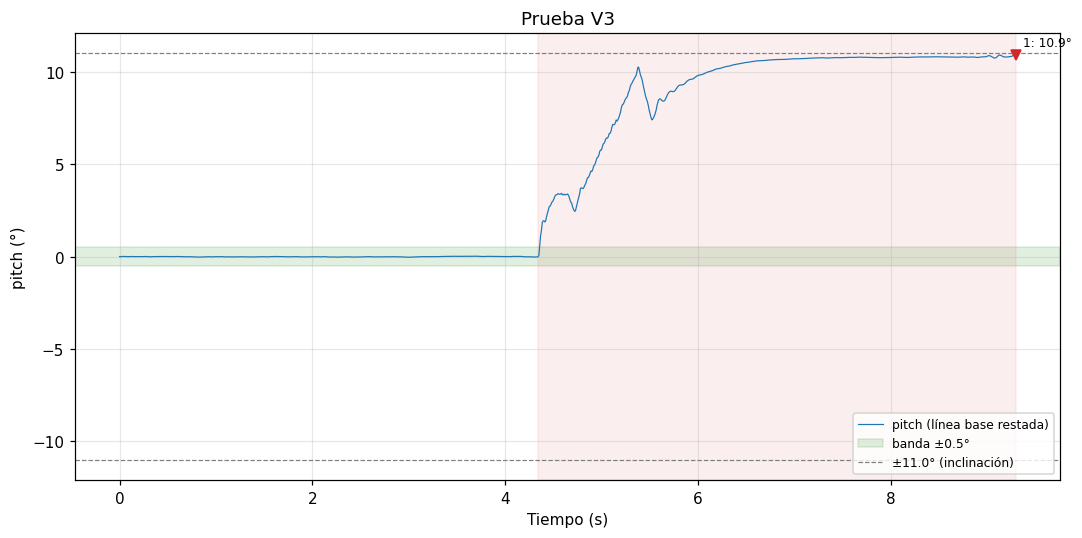

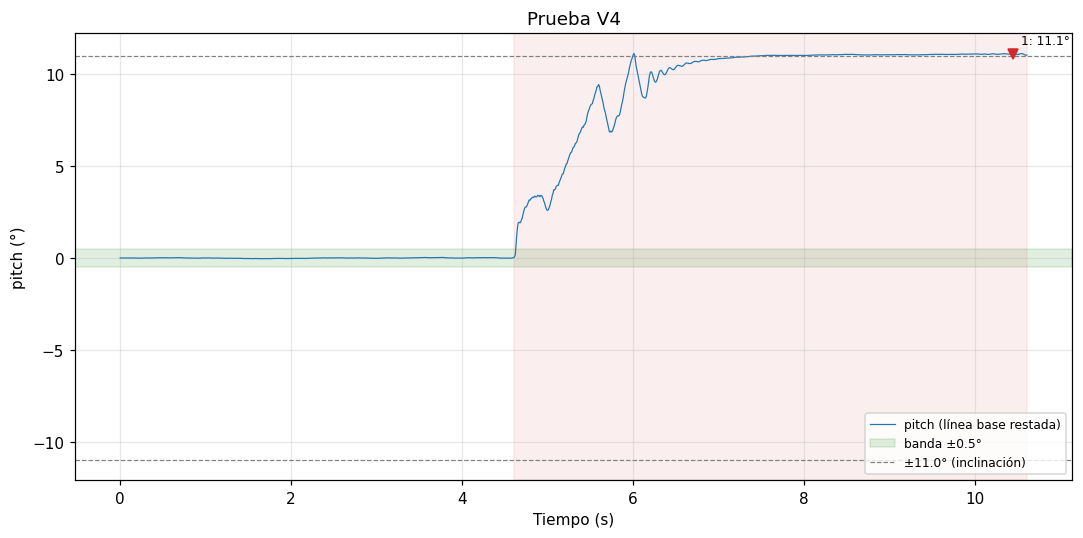

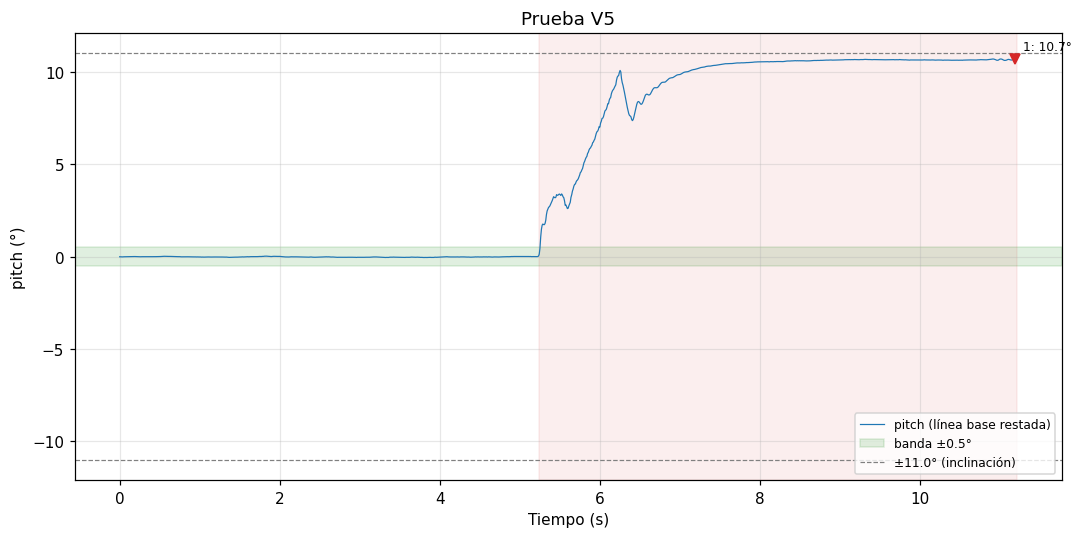

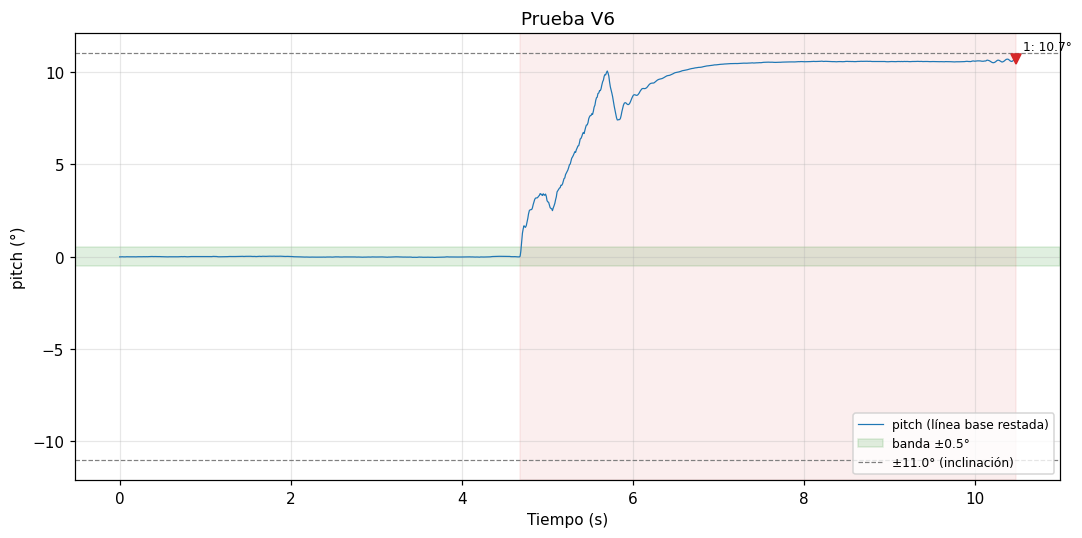

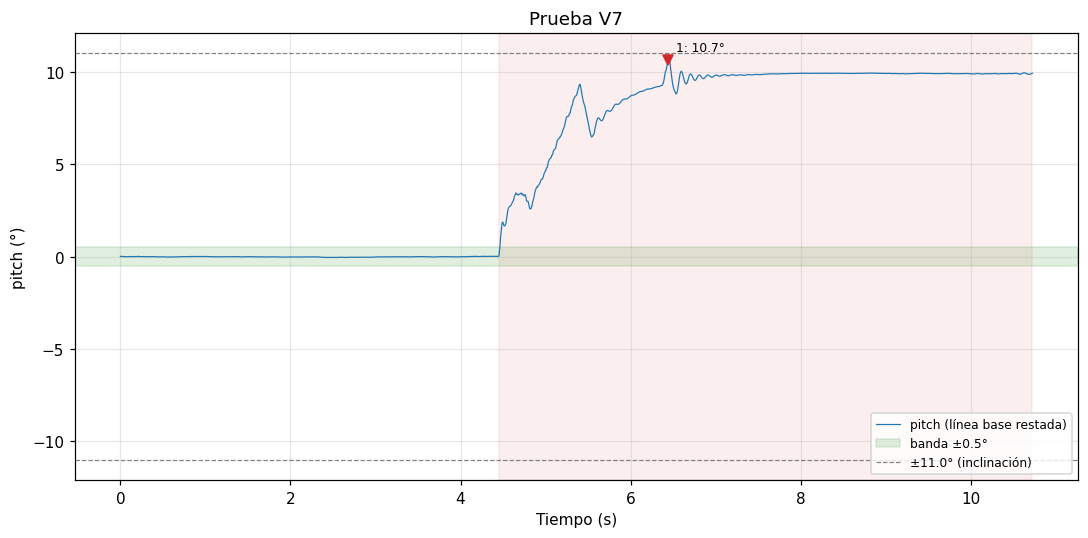

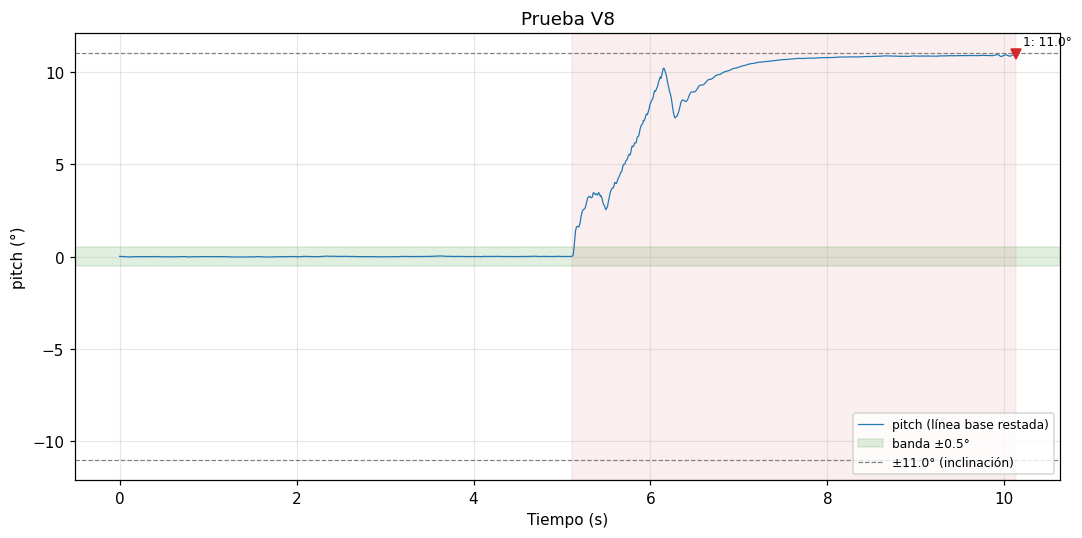

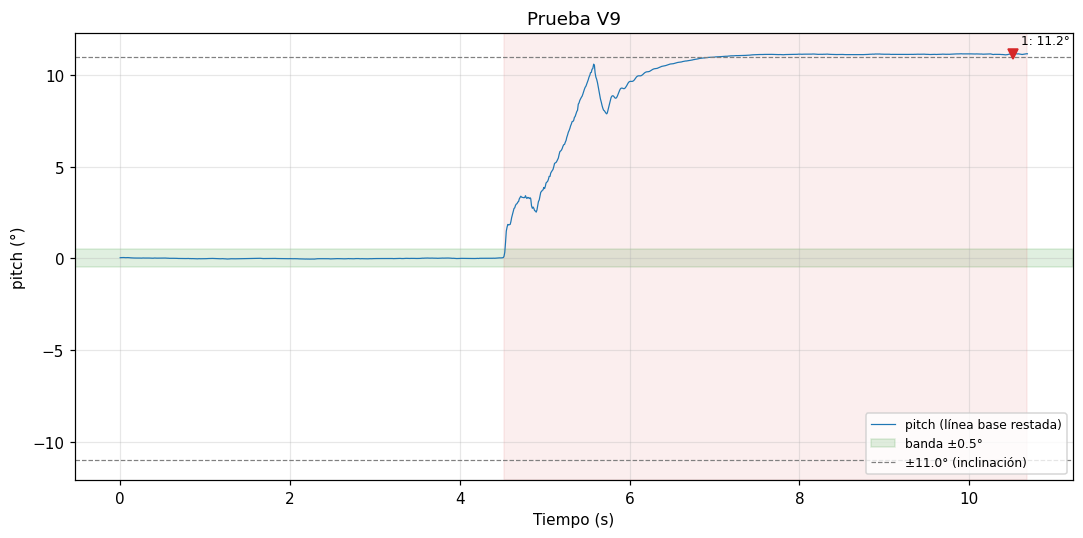

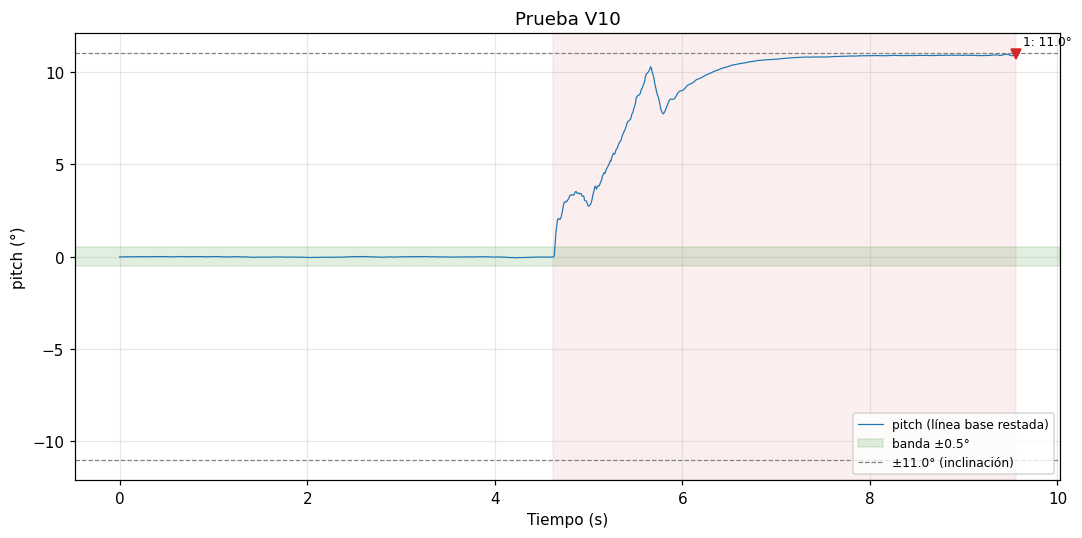

In [ ]:
# Celda 6: series de cada prueba con las excursiones marcadas
for nombre, d in datos.items():
    t = d['t'].values; S = señales[nombre]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(t, S['xc'], lw=.8, color='C0', label='pitch (línea base restada)')
    ax.axhspan(-BAND_DEG, BAND_DEG, color='g', alpha=.12, label=f'banda ±{BAND_DEG}°')
    for s in (+1, -1):
        ax.axhline(s * TILT_DEG, color='gray', ls='--', lw=.8,
                   label=f'±{TILT_DEG}° (inclinación)' if s > 0 else None)
    for e in S['exc']:
        col = 'tab:red' if e['signo'] == '+' else 'tab:purple'
        ax.axvspan(t[e['i_on']], t[e['i_fin']], color=col, alpha=.08)
        ax.plot(t[e['i_pk']], S['xc'][e['i_pk']], 'v', color=col)
        ax.annotate(f"{e['n']}: {e['pico']:.1f}°", (t[e['i_pk']], S['xc'][e['i_pk']]),
                    textcoords='offset points', xytext=(5, 6 if e['signo'] == '+' else -14),
                    fontsize=8)
    ax.set_ylabel('pitch (°)'); ax.set_xlabel('Tiempo (s)'); ax.set_title(f'Prueba {nombre}')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout(); plt.savefig(f'{OUT_DIR}/{nombre}_series.png'); plt.show()

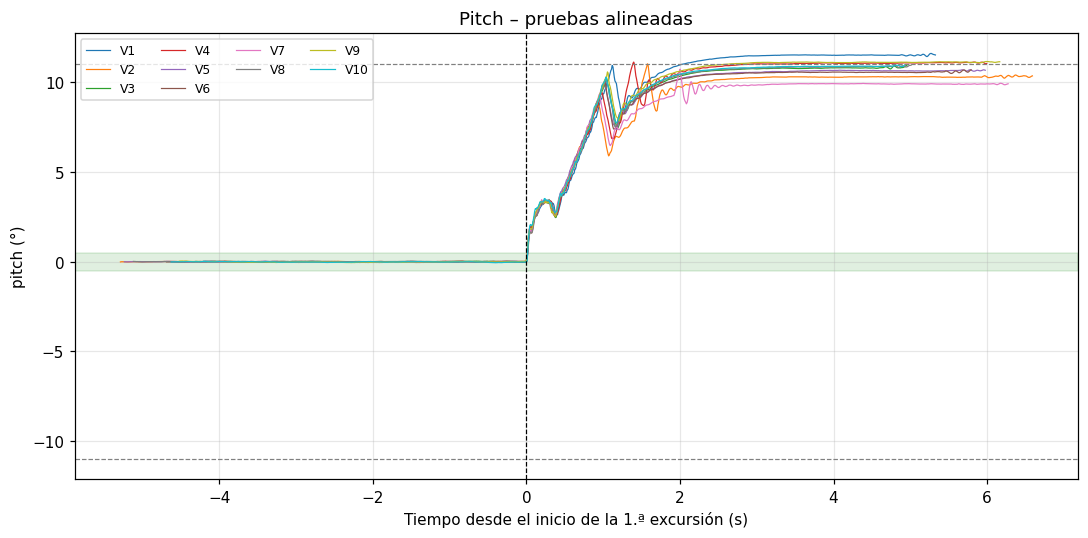

In [ ]:
# Celda 7: pruebas alineadas en el inicio de la 1.ª excursión
fig, ax = plt.subplots(figsize=(10, 5))
for nombre, d in datos.items():
    S = señales[nombre]
    if not S['exc']: continue
    t0 = d['t'].values[S['exc'][0]['i_on']]
    ax.plot(d['t'].values - t0, S['xc'], lw=.8, label=nombre)
for s in (+1, -1):
    ax.axhline(s * TILT_DEG, color='gray', ls='--', lw=.8)
ax.axhspan(-BAND_DEG, BAND_DEG, color='g', alpha=.12)
ax.axvline(0, color='k', ls='--', lw=.8)
ax.set_xlabel('Tiempo desde el inicio de la 1.ª excursión (s)'); ax.set_ylabel('pitch (°)')
ax.set_title('Pitch – pruebas alineadas'); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/alineadas.png'); plt.show()


In [ ]:
# Celda: verificación explícita — Tabla 1 (pitch sin control, n = 10)
final_sc = df_res['final']
pico_sc  = df_exc.xs(1, level='n')['pico_abs']
sobreimpulso_sc = 100 * (pico_sc - final_sc) / final_sc

tabla1 = pd.DataFrame({
    'Métrica': ['Pico de pitch', 'Pico respecto a la inclinación geométrica',
                'Valor final (estado estacionario)', 'Sobreimpulso (pico vs. valor final)'],
    'Valor (media ± DE)': [
        f"{pico_sc.mean():.2f}° ± {pico_sc.std():.2f}°",
        f"{100 * pico_sc.mean() / th_geom:.1f}%",
        f"{final_sc.mean():.2f}° ± {final_sc.std():.2f}°",
        f"{sobreimpulso_sc.mean():.1f}% ± {sobreimpulso_sc.std():.1f}%",
    ]
}).set_index('Métrica')
display(tabla1) if 'display' in globals() else print(tabla1)

                                          Valor (media ± DE)
Métrica                                                     
Pico de pitch                                 10.97° ± 0.29°
Pico respecto a la inclinación geométrica              98.9%
Valor final (estado estacionario)             10.78° ± 0.45°
Sobreimpulso (pico vs. valor final)              1.8% ± 2.5%


**PRUEBAS CON CONTROL**

In [ ]:
# Celda 3: cargar archivos (sube los .txt o usa los que ya estén en la carpeta)
try:
    from google.colab import files
    subidos = files.upload()          # selecciona PitchV1.txt ... PitchV8.txt
    rutas = list(subidos.keys())
except ImportError:                   # fuera de Colab: busca en la carpeta actual
    rutas = glob.glob('*Pitch*.txt')

def num_prueba(ruta):
    m = re.search(r'V(\d+)', os.path.basename(ruta))
    return int(m.group(1)) if m else 0

rutas = sorted(rutas, key=num_prueba)
print('Archivos:', [os.path.basename(r) for r in rutas])


Saving PitchV1.txt to PitchV1 (4).txt
Saving PitchV2.txt to PitchV2 (4).txt
Saving PitchV3.txt to PitchV3 (4).txt
Saving PitchV4.txt to PitchV4 (4).txt
Saving PitchV7.txt to PitchV7 (4).txt
Saving PitchV8.txt to PitchV8 (4).txt
Saving PitchV9.txt to PitchV9 (4).txt
Saving PitchV10.txt to PitchV10 (4).txt
Saving PitchV11.txt to PitchV11 (4).txt
Saving PitchV12.txt to PitchV12 (4).txt
Saving PitchV13.txt to PitchV13 (4).txt
Saving PitchV14.txt to PitchV14 (4).txt
Saving PitchV15.txt to PitchV15 (4).txt
Saving PitchV16.txt to PitchV16 (4).txt
Saving PitchV18.txt to PitchV18 (4).txt
Saving PitchV19.txt to PitchV19 (4).txt
Archivos: ['PitchV1 (4).txt', 'PitchV2 (4).txt', 'PitchV3 (4).txt', 'PitchV4 (4).txt', 'PitchV7 (4).txt', 'PitchV8 (4).txt', 'PitchV9 (4).txt', 'PitchV10 (4).txt', 'PitchV11 (4).txt', 'PitchV12 (4).txt', 'PitchV13 (4).txt', 'PitchV14 (4).txt', 'PitchV15 (4).txt', 'PitchV16 (4).txt', 'PitchV18 (4).txt', 'PitchV19 (4).txt']


In [ ]:
# Celda 4: lectura robusta (ignora "ERROR: MPU6050...", basura serial, timestamps)
LINEA = re.compile(r'(\d+),(-?\d+(?:\.\d+)?),(-?\d+(?:\.\d+)?)\s*$')

def cargar(ruta):
    filas = []
    with open(ruta, 'r', errors='ignore') as f:
        for linea in f:
            m = LINEA.search(linea.strip())
            if m:
                filas.append(tuple(float(x) for x in m.groups()))
    df = pd.DataFrame(filas, columns=['millis', 'roll', 'pitch'])   # <- orden real
    df = df[df['millis'].diff().fillna(1) > 0].reset_index(drop=True)
    df['t'] = (df['millis'] - df['millis'].iloc[0]) / 1000.0
    return df

datos = {f'V{num_prueba(r)}': cargar(r) for r in rutas}

resumen_carga = pd.DataFrame({
    k: {'muestras': len(d),
        'duración (s)': round(d['t'].iloc[-1], 2),
        'dt mediano (ms)': d['millis'].diff().median(),
        'fs (Hz)': round(1000 / d['millis'].diff().median(), 1),
        'huecos >50 ms': int((d['millis'].diff() > 50).sum())}
    for k, d in datos.items()}).T
display(resumen_carga) if 'display' in globals() else print(resumen_carga)


     muestras  duración (s)  dt mediano (ms)  fs (Hz)  huecos >50 ms
V1     1125.0         10.27              9.0    111.1            0.0
V2     1175.0         10.73              9.0    111.1            0.0
V3     1188.0         10.85              9.0    111.1            0.0
V4     1254.0         11.45              9.0    111.1            0.0
V7     1239.0         11.32              9.0    111.1            0.0
V8     1216.0         11.11              9.0    111.1            0.0
V9     1831.0         16.73              9.0    111.1            0.0
V10    1294.0         11.81              9.0    111.1            0.0
V11    1125.0         10.27              9.0    111.1            0.0
V12    1175.0         10.73              9.0    111.1            0.0
V13    1188.0         10.85              9.0    111.1            0.0
V14    1161.0          8.58              9.0    111.1            0.0
V15    1341.0         12.24              9.0    111.1            0.0
V16    1305.0         11.92       

In [ ]:
# Celda 5: detección de excursiones y métricas
trapecio = getattr(np, 'trapezoid', None) or np.trapz   # compatible NumPy 1.x y 2.x

def suavizar(x, fs):
    v = int(round(SMOOTH_S * fs)); v += (v % 2 == 0); v = max(v, 5)
    return savgol_filter(x, v, 3)

def encontrar_excursiones(t, xs):
    """Tramos consecutivos con |pitch| > BAND, del mismo signo y sin huecos > GAP_S."""
    idx = np.flatnonzero(np.abs(xs) > BAND_DEG)
    if len(idx) == 0:
        return []
    tramos, ini, prev = [], idx[0], idx[0]
    for i in idx[1:]:
        if (t[i] - t[prev] > GAP_S) or (np.sign(xs[i]) != np.sign(xs[prev])):
            tramos.append((ini, prev)); ini = i
        prev = i
    tramos.append((ini, prev))
    return tramos

def analizar_prueba(d):
    t = d['t'].values
    fs = 1 / np.median(np.diff(t))
    x = d['pitch'].values
    base_mask = t <= t[0] + BASELINE_S
    base, ruido = x[base_mask].mean(), x[base_mask].std()
    xc = x - base                                   # línea base restada
    xs = suavizar(xc, fs)
    w = np.gradient(xs, t)                          # velocidad angular (°/s)

    umbral_on = max(5 * ruido, ONSET_MIN_DEG)
    excursiones = []
    for (a, b) in encontrar_excursiones(t, xs):
        i_pk = a + np.argmax(np.abs(xs[a:b + 1]))
        if abs(xc[i_pk]) < LOBULO_MIN_DEG:
            continue                                # transitorios menores
        # inicio: retrocede hasta que |xs| cae bajo el umbral de inicio
        i_on = i_pk
        while i_on > 0 and abs(xs[i_on]) > umbral_on:
            i_on -= 1
        i_fin = b                                   # último instante fuera de banda
        tramo = slice(i_on, i_fin + 1)
        excursiones.append(dict(
            signo='+' if xc[i_pk] > 0 else '-',
            t_inicio=t[i_on], t_pico=t[i_pk], t_fin=t[i_fin],
            pico=xc[i_pk], pico_abs=abs(xc[i_pk]),
            pico_mm_equiv=grados_a_mm(abs(xc[i_pk])),
            pico_pct_inclinacion=100 * abs(xc[i_pk]) / TILT_DEG,
            t_subida=t[i_pk] - t[i_on],
            t_recuperacion=t[i_fin] - t[i_pk],
            duracion=t[i_fin] - t[i_on],
            pendiente_max=np.max(np.abs(w[i_on:i_pk + 1])) if i_pk > i_on else np.nan,
            area_error=trapecio(np.abs(xc[tramo]), t[tramo]),   # °·s
            i_on=i_on, i_pk=i_pk, i_fin=i_fin))
    for k, e in enumerate(excursiones, 1):
        e['n'] = k

    # meseta entre la 1.ª y la 2.ª excursión (plataforma ya corregida sobre la rampa)
    meseta = np.nan
    if len(excursiones) >= 2:
        a, b = excursiones[0]['i_fin'], excursiones[1]['i_on']
        if b > a and t[b] - t[a] > 0.3:
            meseta = xc[a:b].mean()

    tail = t >= t[-1] - FINAL_S
    resumen = dict(
        n_excursiones=len(excursiones),
        secuencia=''.join(e['signo'] for e in excursiones),
        meseta_medio=meseta, final=xc[tail].mean(),
        final_std=xc[tail].std(),
        rms_total=np.sqrt(np.mean(xc ** 2)),
        roll_pico_a_pico=np.ptp(d['roll'].values - d['roll'].values[base_mask].mean()),
        ruido_reposo=ruido)
    return excursiones, resumen, xc, xs, w

exc_rows, res_rows, señales = [], [], {}
for nombre, d in datos.items():
    exc, res, xc, xs, w = analizar_prueba(d)
    señales[nombre] = dict(xc=xc, xs=xs, w=w, exc=exc)
    res['prueba'] = nombre; res_rows.append(res)
    for e in exc:
        exc_rows.append({**{k: v for k, v in e.items() if not k.startswith('i_')},
                         'prueba': nombre})

df_res = pd.DataFrame(res_rows).set_index('prueba')
df_exc = pd.DataFrame(exc_rows).set_index(['prueba', 'n'])

cols_exc = ['signo', 't_inicio', 't_pico', 'pico', 'pico_mm_equiv',
            'pico_pct_inclinacion', 't_subida', 't_recuperacion',
            'pendiente_max', 'area_error']
print('=== Excursiones detectadas por prueba (ordenadas en el tiempo) ===')
tabla_exc = df_exc[cols_exc].round(3)
display(tabla_exc) if 'display' in globals() else print(tabla_exc)
print('\n=== Resumen por prueba ===')
tabla_res = df_res.round(3)
display(tabla_res) if 'display' in globals() else print(tabla_res)

print(f"\nPico máximo observado: {df_exc['pico_abs'].max():.2f}° "
      f"({df_exc['pico_mm_equiv'].max():.1f} mm equivalentes) | "
      f"inclinación aplicada: {TILT_DEG}° | límite de compensación: {th_max:.1f}°")


=== Excursiones detectadas por prueba (ordenadas en el tiempo) ===
         signo  t_inicio  t_pico   pico  pico_mm_equiv  pico_pct_inclinacion  \
prueba n                                                                       
V1     1     +     3.349   4.272  6.596         29.485                59.960   
V2     1     +     3.587   4.455  7.061         31.585                64.190   
V3     1     +     3.661   4.512  6.240         27.884                56.731   
V4     1     +     4.336   5.288  5.571         24.872                50.644   
V7     1     +     4.291   5.205  5.908         26.386                53.707   
V8     1     +     3.754   4.695  5.281         23.570                48.009   
V9     1     +    10.074  11.042  5.619         25.090                51.085   
V10    1     +     4.336   5.780  5.569         24.862                50.625   
V11    1     +     3.349   4.272  6.596         29.485                59.960   
V12    1     +     3.587   4.455  7.061         31.58

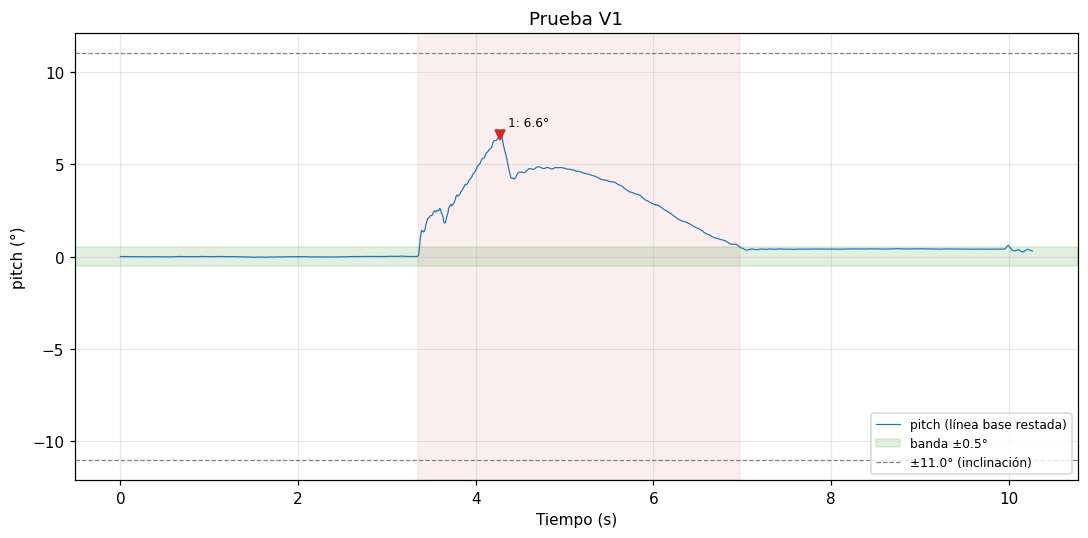

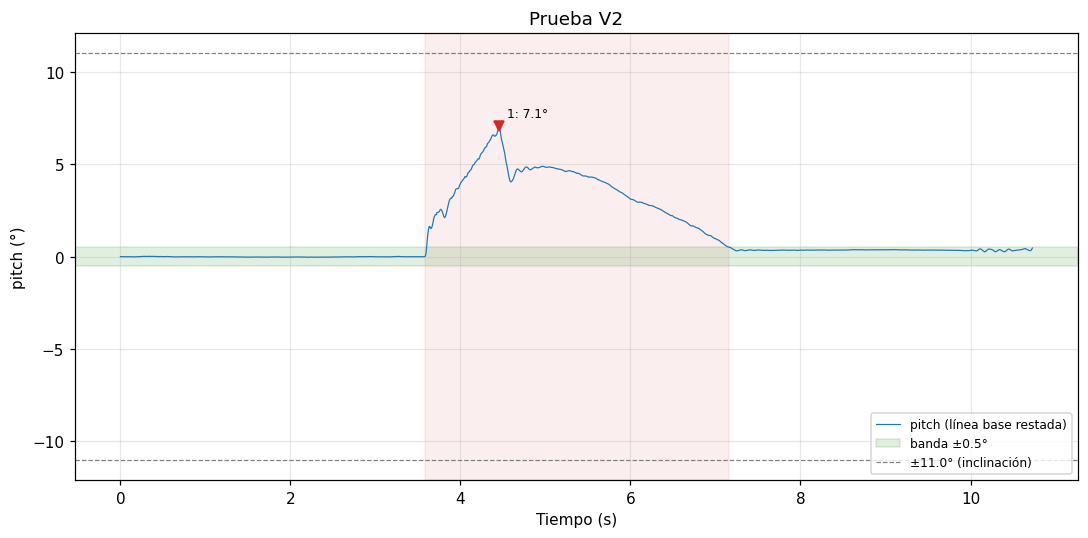

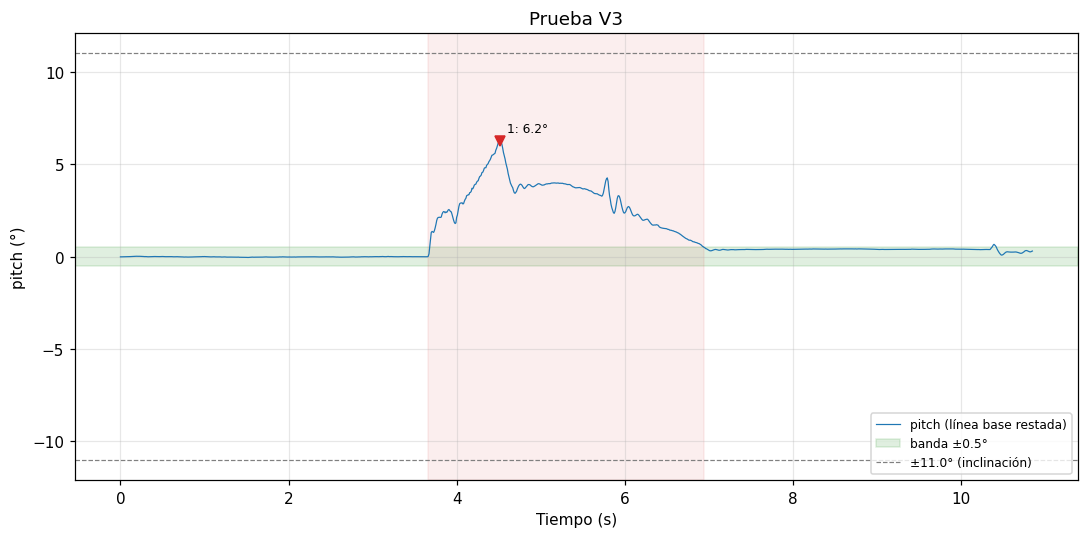

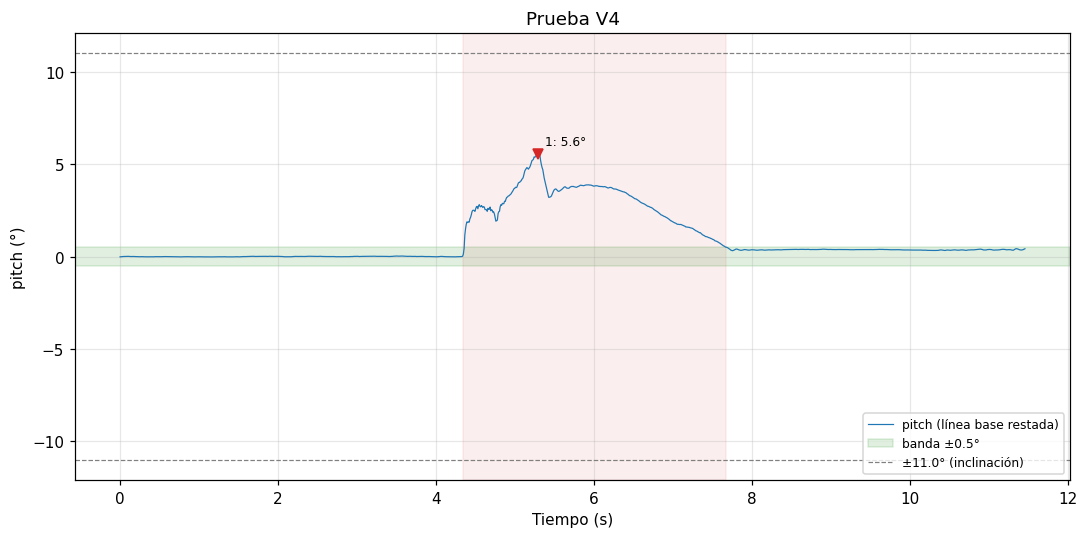

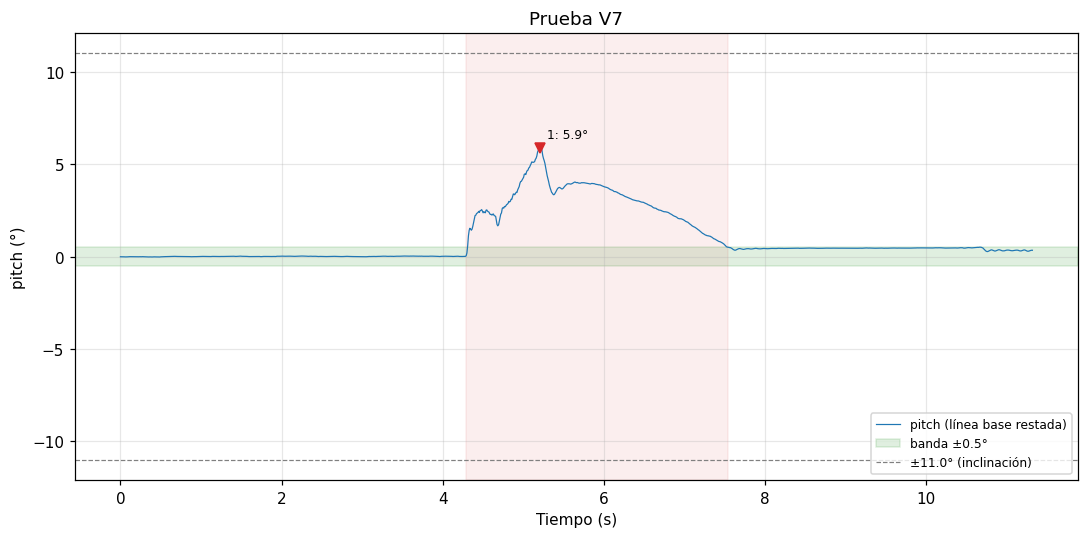

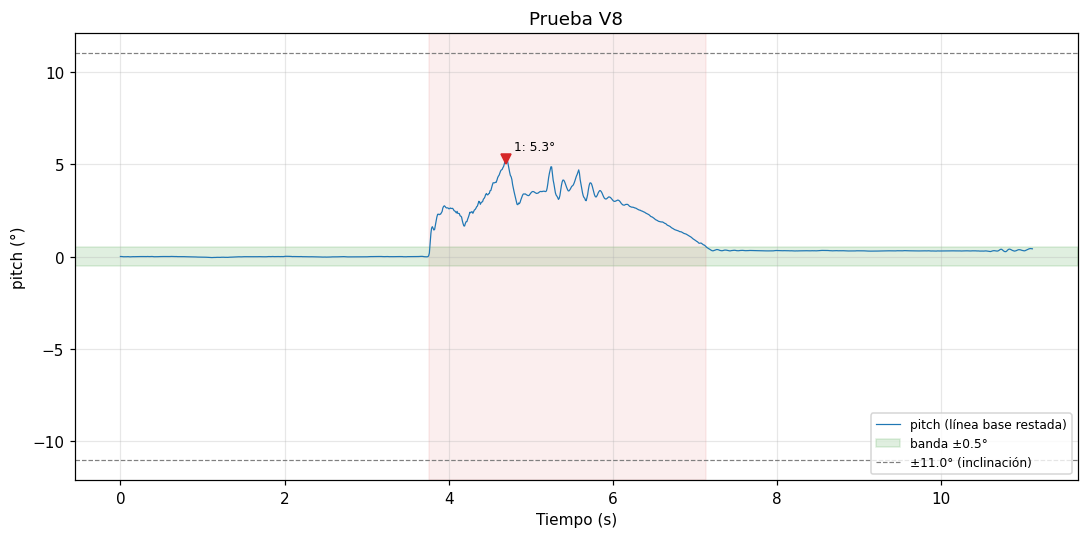

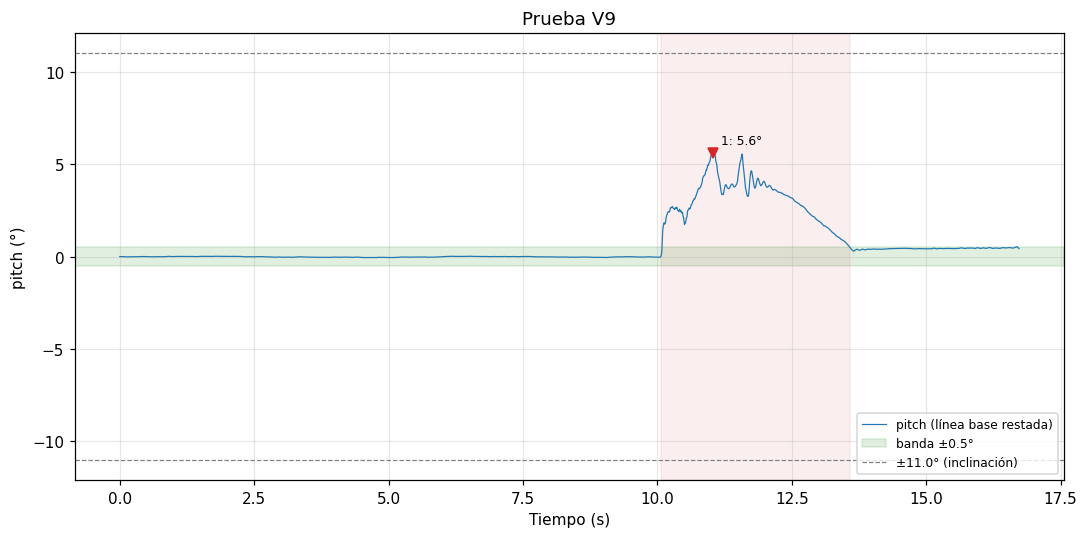

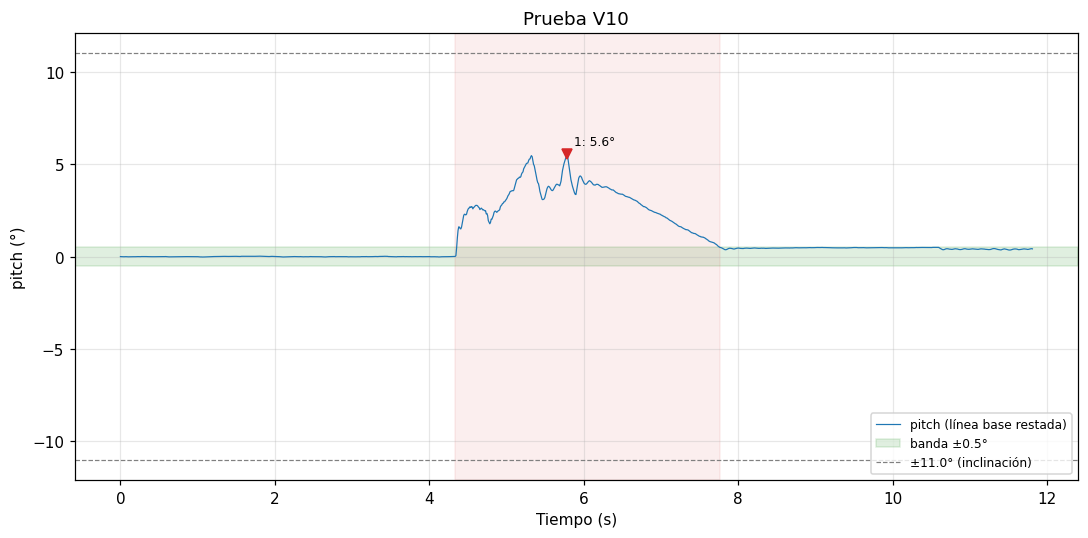

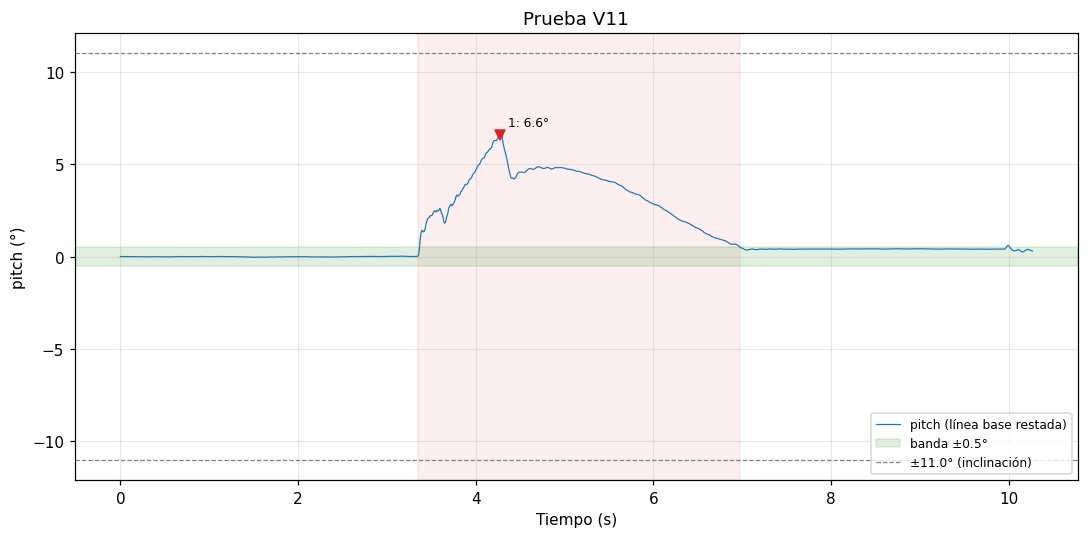

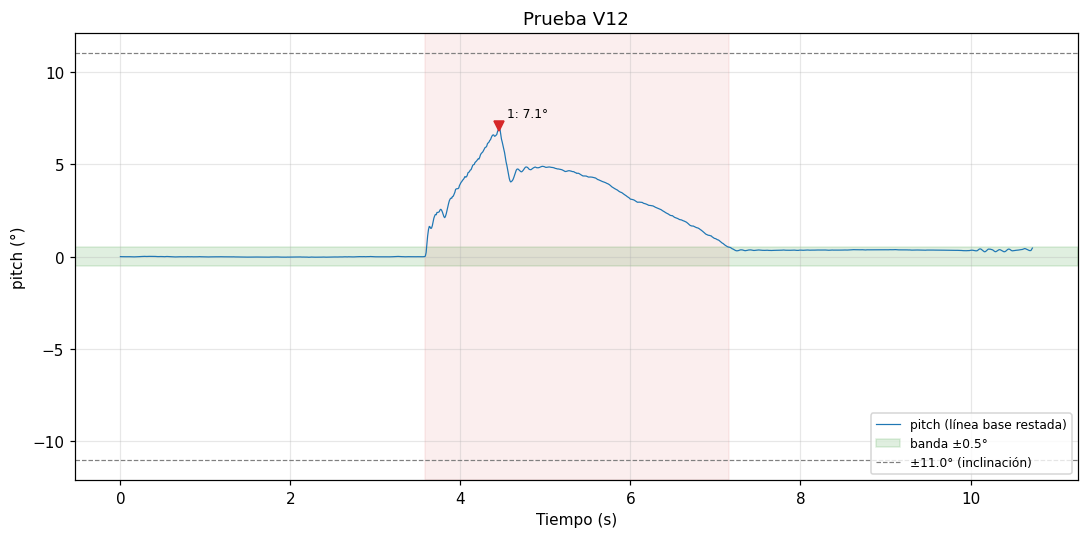

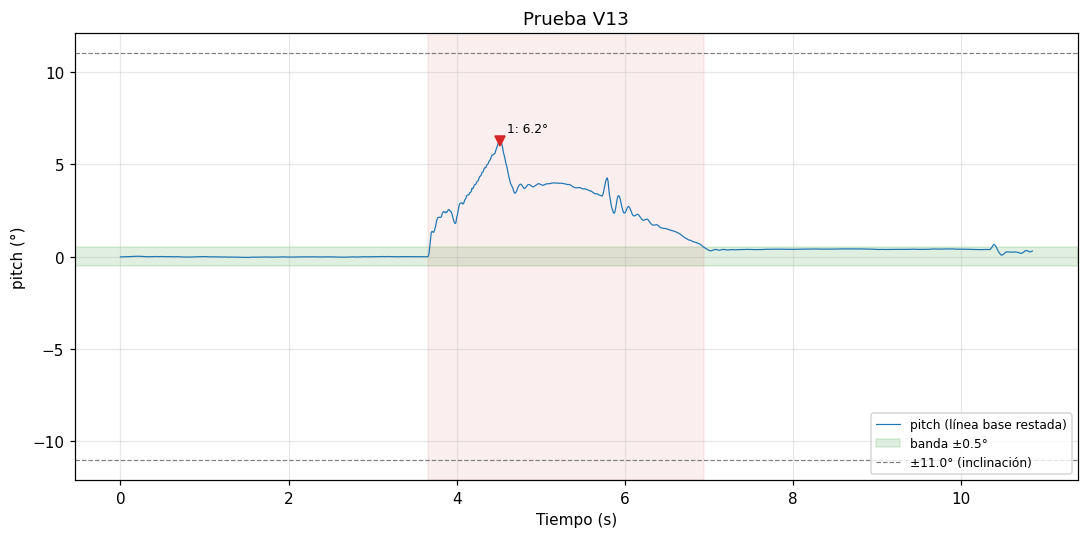

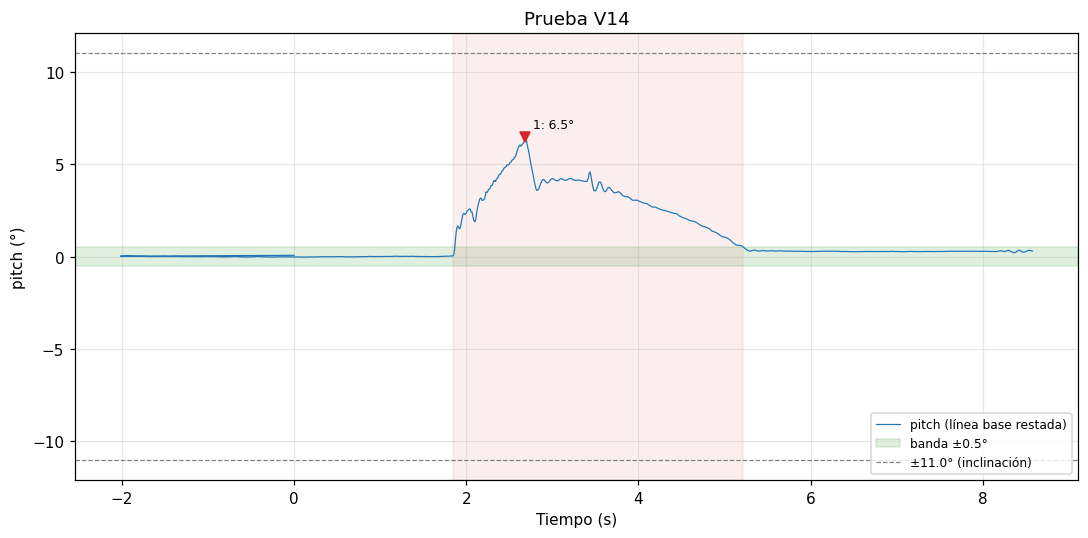

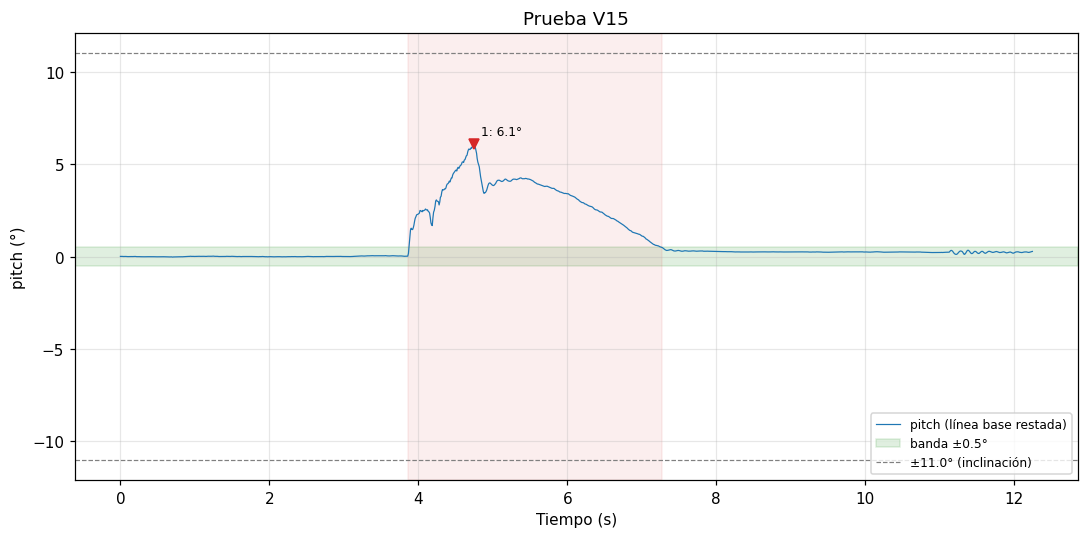

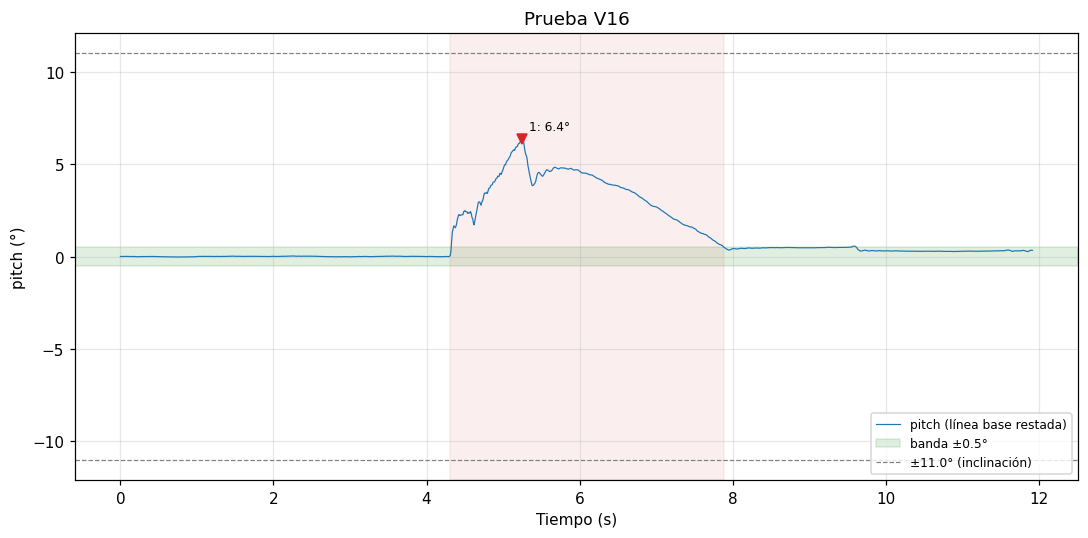

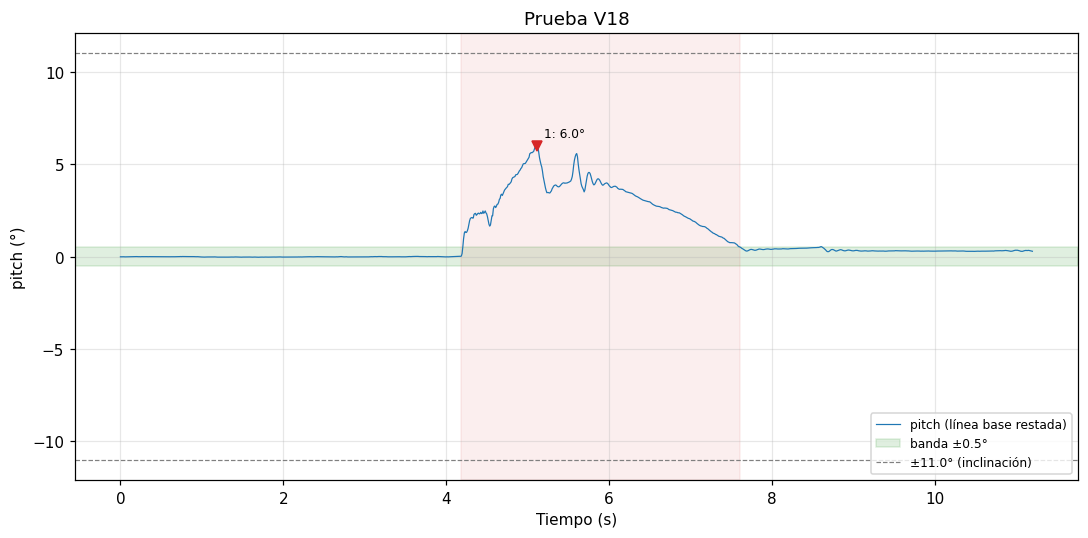

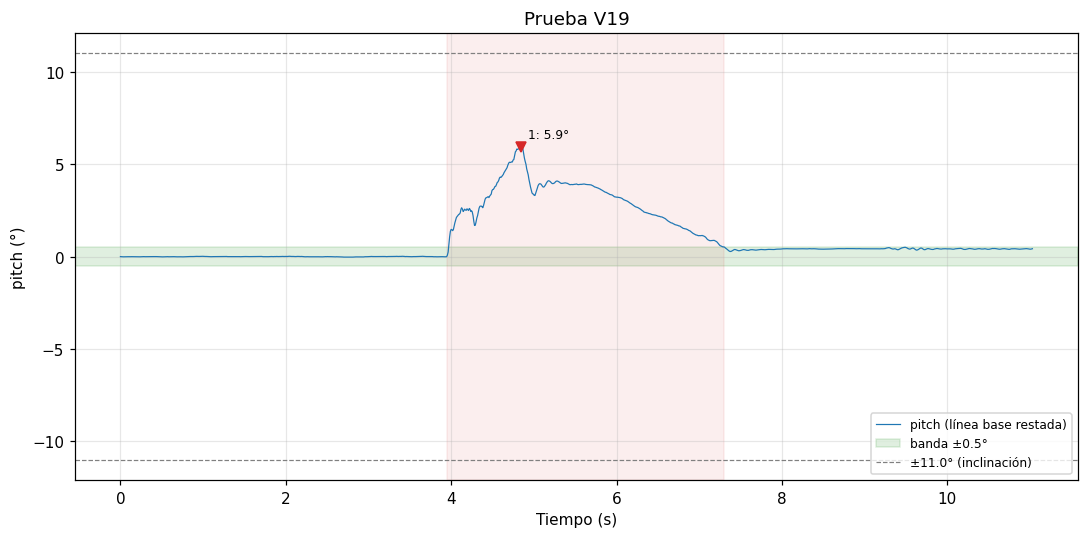

In [ ]:
# Celda 6: series de cada prueba con las excursiones marcadas
for nombre, d in datos.items():
    t = d['t'].values; S = señales[nombre]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(t, S['xc'], lw=.8, color='C0', label='pitch (línea base restada)')
    ax.axhspan(-BAND_DEG, BAND_DEG, color='g', alpha=.12, label=f'banda ±{BAND_DEG}°')
    for s in (+1, -1):
        ax.axhline(s * TILT_DEG, color='gray', ls='--', lw=.8,
                   label=f'±{TILT_DEG}° (inclinación)' if s > 0 else None)
    for e in S['exc']:
        col = 'tab:red' if e['signo'] == '+' else 'tab:purple'
        ax.axvspan(t[e['i_on']], t[e['i_fin']], color=col, alpha=.08)
        ax.plot(t[e['i_pk']], S['xc'][e['i_pk']], 'v', color=col)
        ax.annotate(f"{e['n']}: {e['pico']:.1f}°", (t[e['i_pk']], S['xc'][e['i_pk']]),
                    textcoords='offset points', xytext=(5, 6 if e['signo'] == '+' else -14),
                    fontsize=8)
    ax.set_ylabel('pitch (°)'); ax.set_xlabel('Tiempo (s)'); ax.set_title(f'Prueba {nombre}')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout(); plt.savefig(f'{OUT_DIR}/{nombre}_series.png'); plt.show()

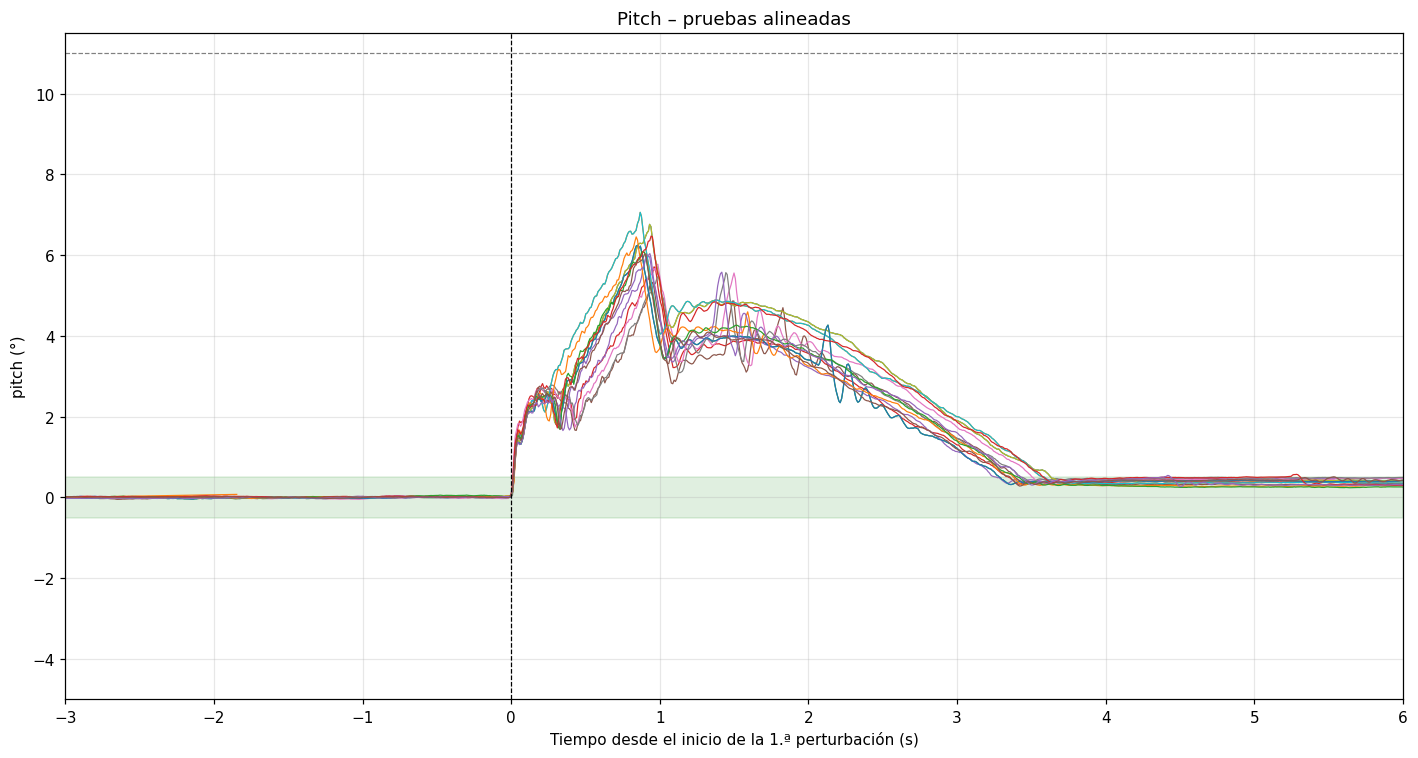

In [ ]:
# Celda 7: pruebas alineadas en el inicio de la 1.ª excursión
fig, ax = plt.subplots(figsize=(13, 7))
for nombre, d in datos.items():
    S = señales[nombre]
    if not S['exc']: continue
    t0 = d['t'].values[S['exc'][0]['i_on']]
    t_rel = d['t'].values - t0
    mask = t_rel >= -3
    ax.plot(t_rel[mask], S['xc'][mask], lw=.8, label=nombre)
for s in (+1, -1):
    ax.axhline(s * TILT_DEG, color='gray', ls='--', lw=.8)
ax.axhspan(-BAND_DEG, BAND_DEG, color='g', alpha=.12)
ax.axvline(0, color='k', ls='--', lw=.8)
ax.set_xlim(left=-3)
ax.set_xlim(right=6)
ax.set_ylim(bottom=-5, top=11.5)
ax.set_xlabel('Tiempo desde el inicio de la 1.ª perturbación (s)'); ax.set_ylabel('pitch (°)')
ax.set_title('Pitch – pruebas alineadas');
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/alineadas.png'); plt.show()

In [ ]:
# Celda: verificación explícita — Tabla 2 (pitch con control, n = 20)
sel = df_exc.xs(1, level='n')   # primera (y única) excursión de cada prueba

tabla2 = pd.DataFrame({
    'Métrica': ['Pico de pitch', 'Pico respecto a la inclinación aplicada',
                'Tiempo al pico (desde inicio)', 'Tiempo de recuperación (pico → banda)',
                'Duración total de la excursión', 'Valor de equilibrio', 'Ruido en reposo'],
    'Valor (media ± DE)': [
        f"{sel['pico_abs'].mean():.2f}° ± {sel['pico_abs'].std():.2f}°",
        f"{sel['pico_pct_inclinacion'].mean():.1f}% ± {sel['pico_pct_inclinacion'].std():.1f}%",
        f"{sel['t_subida'].mean():.2f} s ± {sel['t_subida'].std():.2f} s",
        f"{sel['t_recuperacion'].mean():.2f} s ± {sel['t_recuperacion'].std():.2f} s",
        f"{sel['duracion'].mean():.2f} s ± {sel['duracion'].std():.2f} s",
        f"{df_res['final'].mean():.2f}° ± {df_res['final'].std():.2f}°",
        f"{df_res['ruido_reposo'].mean():.3f}°",
    ]
}).set_index('Métrica')
display(tabla2) if 'display' in globals() else print(tabla2)

                                        Valor (media ± DE)
Métrica                                                   
Pico de pitch                                6.25° ± 0.56°
Pico respecto a la inclinación aplicada       56.8% ± 5.1%
Tiempo al pico (desde inicio)              1.02 s ± 0.31 s
Tiempo de recuperación (pico → banda)      2.41 s ± 0.33 s
Duración total de la excursión             3.43 s ± 0.15 s
Valor de equilibrio                          0.32° ± 0.14°
Ruido en reposo                                     0.008°


In [ ]:
# Celda 3: cargar archivos (sube los .txt o usa los que ya estén en la carpeta)
try:
    from google.colab import files
    subidos = files.upload()          # selecciona PitchV1.txt ... PitchV8.txt
    rutas = list(subidos.keys())
except ImportError:                   # fuera de Colab: busca en la carpeta actual
    rutas = glob.glob('*Pitch*.txt')

def num_prueba(ruta):
    m = re.search(r'V(\d+)', os.path.basename(ruta))
    return int(m.group(1)) if m else 0

rutas = sorted(rutas, key=num_prueba)
print('Archivos:', [os.path.basename(r) for r in rutas])


Saving PitchV1.txt to PitchV1 (3).txt
Saving PitchV2.txt to PitchV2 (3).txt
Saving PitchV3.txt to PitchV3 (3).txt
Saving PitchV4.txt to PitchV4 (3).txt
Saving PitchV7.txt to PitchV7 (3).txt
Saving PitchV8.txt to PitchV8 (3).txt
Saving PitchV9.txt to PitchV9 (3).txt
Saving PitchV10.txt to PitchV10 (3).txt
Saving PitchV11.txt to PitchV11 (3).txt
Saving PitchV12.txt to PitchV12 (3).txt
Saving PitchV13.txt to PitchV13 (3).txt
Saving PitchV14.txt to PitchV14 (3).txt
Saving PitchV15.txt to PitchV15 (3).txt
Saving PitchV16.txt to PitchV16 (3).txt
Saving PitchV18.txt to PitchV18 (3).txt
Saving PitchV19.txt to PitchV19 (3).txt
Archivos: ['PitchV1 (3).txt', 'PitchV2 (3).txt', 'PitchV3 (3).txt', 'PitchV4 (3).txt', 'PitchV7 (3).txt', 'PitchV8 (3).txt', 'PitchV9 (3).txt', 'PitchV10 (3).txt', 'PitchV11 (3).txt', 'PitchV12 (3).txt', 'PitchV13 (3).txt', 'PitchV14 (3).txt', 'PitchV15 (3).txt', 'PitchV16 (3).txt', 'PitchV18 (3).txt', 'PitchV19 (3).txt']


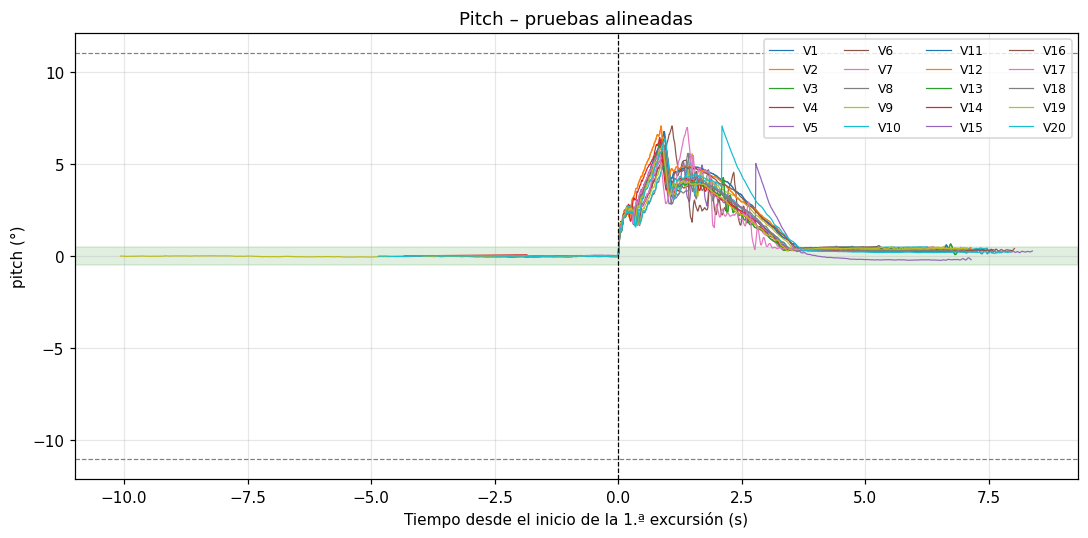

In [ ]:
# Celda 7: pruebas alineadas en el inicio de la 1.ª excursión
fig, ax = plt.subplots(figsize=(10, 5))
for nombre, d in datos.items():
    S = señales[nombre]
    if not S['exc']: continue
    t0 = d['t'].values[S['exc'][0]['i_on']]
    ax.plot(d['t'].values - t0, S['xc'], lw=.8, label=nombre)
for s in (+1, -1):
    ax.axhline(s * TILT_DEG, color='gray', ls='--', lw=.8)
ax.axhspan(-BAND_DEG, BAND_DEG, color='g', alpha=.12)
ax.axvline(0, color='k', ls='--', lw=.8)
ax.set_xlabel('Tiempo desde el inicio de la 1.ª excursión (s)'); ax.set_ylabel('pitch (°)')
ax.set_title('Pitch – pruebas alineadas'); ax.legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/alineadas.png'); plt.show()
